In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyrex.eccentric_extension import get_fit_params, read_pkl

/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/.venv/lib/python3.12/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [ ]:
training_dict = read_pkl("sample_data/pyrexdata_allSXS.pkl")
print(training_dict)

{'A_omega': array([ 0.00772116,  0.00910696, -0.00844978,  0.0199791 , -0.01040082,
       -0.05190747,  0.06675006,  0.09294139, -0.09281779,  0.09649384,
        0.13986115,  0.18309386,  0.04060744,  0.05377801,  0.08900969,
       -0.08896177,  0.09068147, -0.17322069, -0.04902445,  0.08384996,
        0.08394327, -0.16106638,  0.01736922,  0.01966074,  0.0202968 ,
        0.07873506, -0.12885766,  0.15212046,  0.17645848,  0.23809564,
       -0.24122835,  0.27314852, -0.32634801, -0.01669661, -0.06863689,
        0.13372791, -0.14457211,  0.17012681,  0.22193505, -0.35620144,
       -0.05855199, -0.08396974,  0.08637005,  0.08941274,  0.11166159,
        0.12417996,  0.14429523,  0.26022291,  0.01430585,  0.06335075,
       -0.12177499, -0.13965597,  0.16294474,  0.24659201,  0.32889554,
       -0.01333795,  0.06263597,  0.11640542,  0.15991484,  0.2244732 ,
        0.31741529, -0.10788577, -0.00722444, -0.00894435,  0.18303533,
       -0.18958535,  0.21626872,  0.01494426, -0.012

/home/amin/Projects/School/Masters/25_26-Thesis/pyrex/src/pyrex/eccentric_extension.py:427: RuntimeWarning: invalid value encountered in sqrt
  freq = np.sqrt(


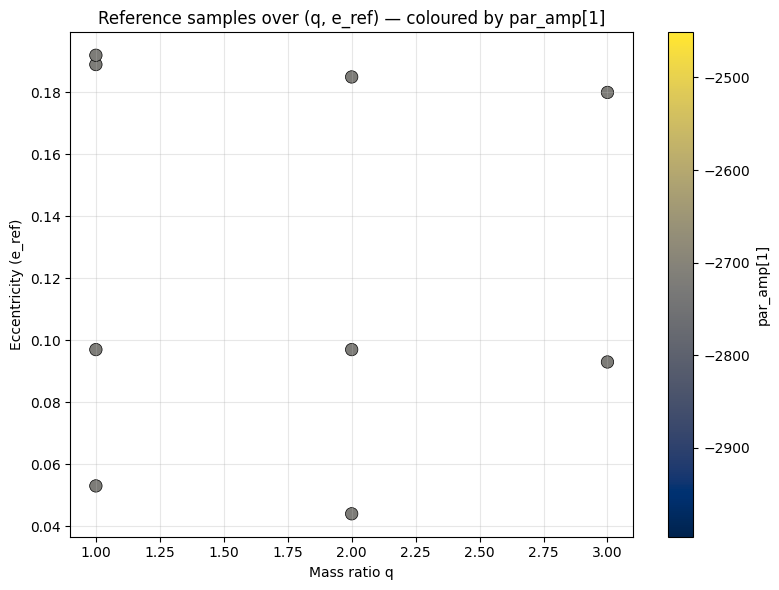

In [3]:
qs = np.array([1, 1, 1, 1, 2.0, 2.0, 2.0, 3.0, 3.0])
e_ref = np.array([0.053, 0.097, 0.189, 0.192, 0.044, 0.097, 0.185, 0.093, 0.18])

x = (20/(2*np.pi))**(2/3)

# compute the value to colour by for each (q, e)
par_vals = []
for q, e in zip(qs, e_ref):
    par_omega, par_amp = get_fit_params(training_dict, q, e, x)
    par_vals.append(par_omega[3])   # or par_amp[0] depending on what you want
par_vals = np.array(par_vals)

# scatter plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(qs, e_ref, c=par_vals, cmap='cividis', s=80, edgecolor='k', linewidth=0.5)
plt.colorbar(sc, label='par_amp[1]')
plt.xlabel("Mass ratio q")
plt.ylabel("Eccentricity (e_ref)")
plt.title("Reference samples over (q, e_ref) — coloured by par_amp[1]")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Clearly interpolation in this way is just going wrong for some reason, there is no reason for the above to look like the situation below when interpolated.

In [5]:
eccentricities = np.linspace(1e-30, 0.2, 50)
mass_ratios = np.linspace(1, 3, 50)

x = (20/(2*np.pi))**(2/3)

grid = np.zeros((len(mass_ratios), len(eccentricities)))

for i, e in enumerate(eccentricities):
    for j, q in enumerate(mass_ratios):
        par_omega, par_amp = get_fit_params(training_dict, q, e, (20/(2*np.pi))**(2/3))

        grid[i, j] = par_omega[0]

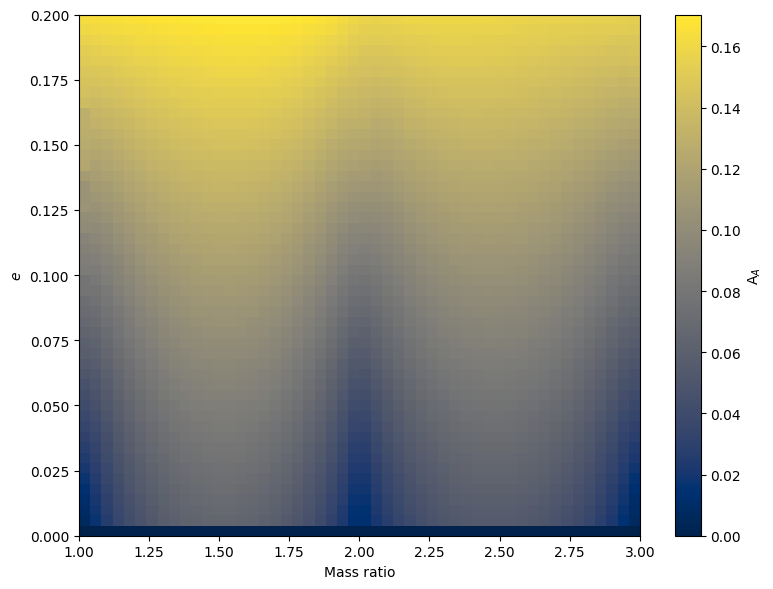

In [6]:
plt.figure(figsize=(8, 6))
plt.imshow(grid, origin='lower', aspect='auto',
           extent=[mass_ratios.min(), mass_ratios.max(), 
                   eccentricities.min(), eccentricities.max()],
           cmap='cividis',)
plt.colorbar(label=r"A$_A$")
plt.xlabel(r"Mass ratio")
plt.ylabel(r"$e$")
# plt.title("Mismatch Heatmap: IMRPhenomD Eccentric vs Circular")
plt.tight_layout()
plt.show()